# TRABAJO PRÁCTICO 1: FILTRADO E IDENTIFICACIÓN DE SISTEMAS (PREENTREGA)

**Cátedra:** Procesamiento Digital de Señales  
**Integrantes:** Ferreyra Florencia, González Tomás, Molina Lara y Scafati Jerónimo.  
**Fecha:** 08/06/2026

---

## 0. Importación de Librerías y Dependencias

Las funciones de procesamiento y visualización se centralizan en `functions.py` para evitar duplicación de código.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd() / "faculty" / "preentrega"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

from functions import (
    graficar_temp,
    graficar_frecuencias,
    rta_frecuencia,
    suma_tonos_puros,
    suma_musical,
    filtro_media_movil,
    filtro_peine,
    filtro_fir,
    filtrar_frecuencia_manual,
    generate_impulse,
    compute_frequency_response,
    plot_frequency_response,
    convolve_time,
    convolve_frequency,
    truncate_fir,
    plot_signal,
    plot_spectrum,
    load_audio,
    load_fir_coefficients,
    apply_fir,
    compute_fft,
    generate_pure_tones,
    add_white_noise
)

## 1. Respuesta al Impulso de los Filtros

La **respuesta al impulso** $h[n]$ es la salida de un sistema LTI ante una delta discreta $\delta[n]$. Caracteriza completamente al sistema: cualquier salida $y[n]$ ante una entrada arbitraria $x[n]$ se obtiene por convolución lineal:

$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]\, h[n-k]$$

Se calculó $h[n]$ para los tres filtros:
1. **Media Móvil** (ventana $M=8$, 1 pasada).
2. **Filtro Peine** (coeficientes $b_0=0.5$, $b_1=0.3$, $b_2=0.2$).
3. **Filtro FIR** (ventana Hamming, provisto por la cátedra).

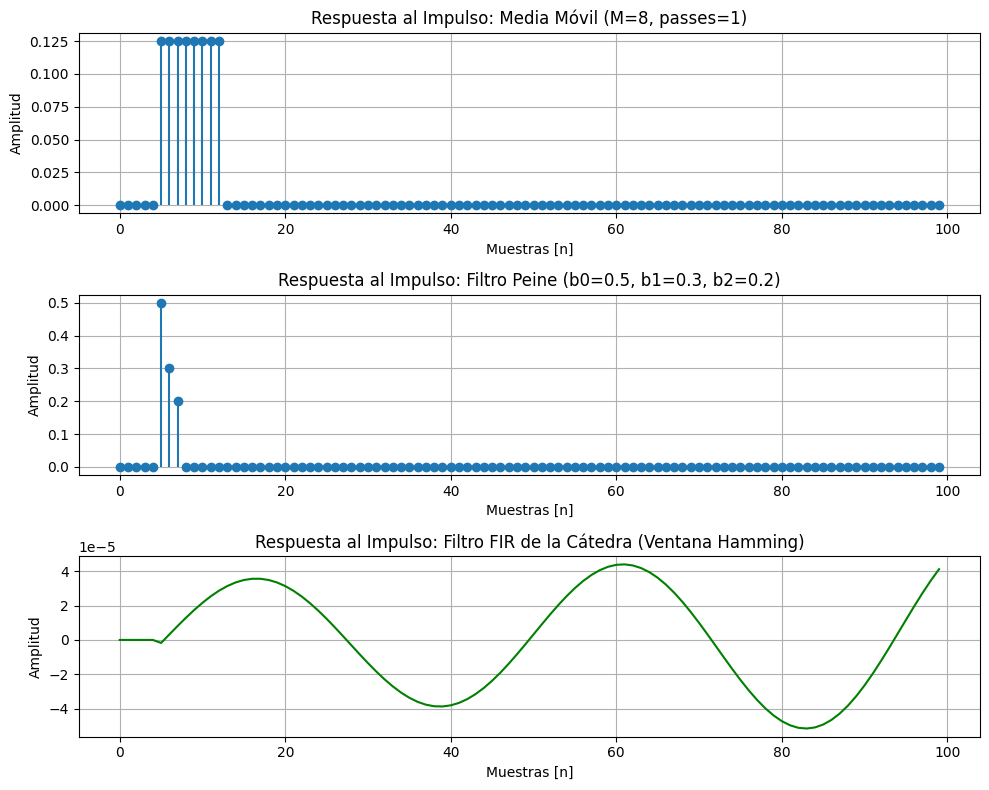

In [3]:
# 1. Generamos un impulso de longitud 100 con un delay de 5 para visualizarlo claramente
length = 100
impulse = generate_impulse(length, delay=5)

# 2. Pasamos el impulso por los distintos filtros para extraer h[n]
h_ma, _ = filtro_media_movil(impulse, m=8, p=1)
h_comb, _ = filtro_peine(impulse, a=0.5, b=0.3, c=0.2)
h_fir, _ = filtro_fir(impulse)

# 3. Graficamos las respuestas al impulso
t_axis = np.arange(length)
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.stem(t_axis, h_ma, basefmt=" ")
plt.title("Respuesta al Impulso: Media Móvil (M=8, passes=1)")
plt.xlabel("Muestras [n]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(t_axis, h_comb, basefmt=" ")
plt.title("Respuesta al Impulso: Filtro Peine (b0=0.5, b1=0.3, b2=0.2)")
plt.xlabel("Muestras [n]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_axis, h_fir[:length], color='green')
plt.title("Respuesta al Impulso: Filtro FIR de la Cátedra (Ventana Hamming)")
plt.xlabel("Muestras [n]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

### Análisis y Conclusiones de la Sección 1:
- **Filtro de Media Móvil (MA)**: $h[n]$ es un pulso rectangular de amplitud $1/M = 0.125$ y duración $M=8$ muestras, consistente con el promedio aritmético de las últimas $M$ muestras.
- **Filtro Peine**: Muestra exactamente 3 muestras no nulas ($b_0, b_1, b_2$) en los instantes $n=5, 6, 7$, verificando su carácter FIR causal de orden 2.
- **Filtro FIR de la Cátedra**: Respuesta de mayor duración con forma de sinc suavizada por la ventana Hamming. La simetría alrededor del pico central confirma fase lineal.

## 2. Caracterización en Frecuencia

La respuesta en frecuencia $H(\omega)$ describe la ganancia y el desfase que introduce el filtro en cada componente frecuencial:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)}$$

Al excitar con un impulso unitario ($X(\omega)=1$), la respuesta en frecuencia coincide con la transformada de Fourier de $h[n]$:

$$H(\omega) = \mathcal{F}\{h[n]\}$$

Se grafican el módulo (en dB) y la fase (en radianes) de los tres filtros.

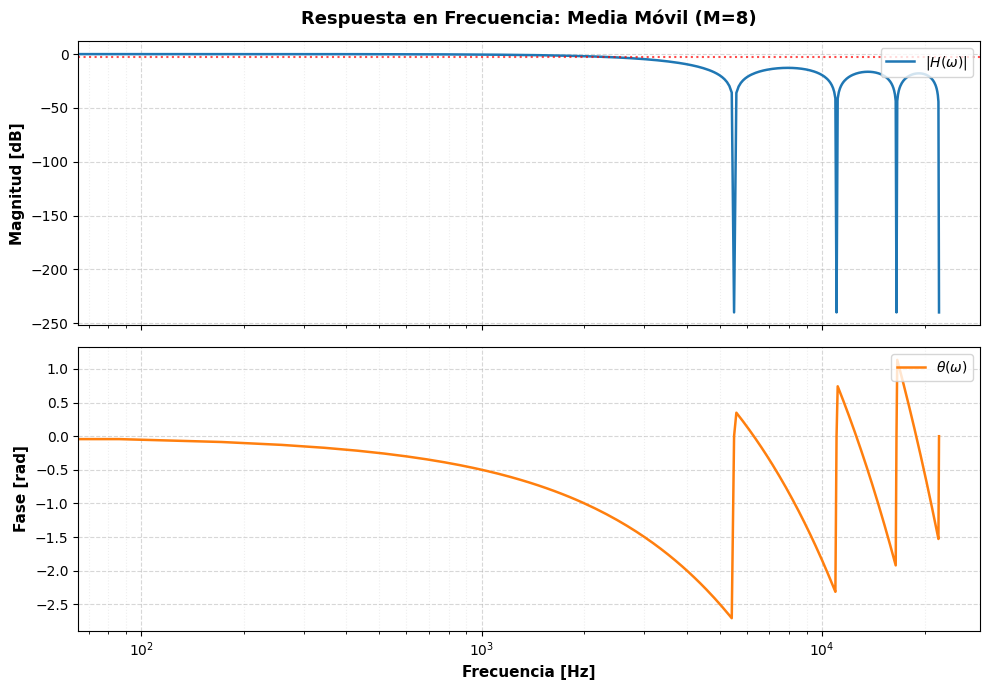

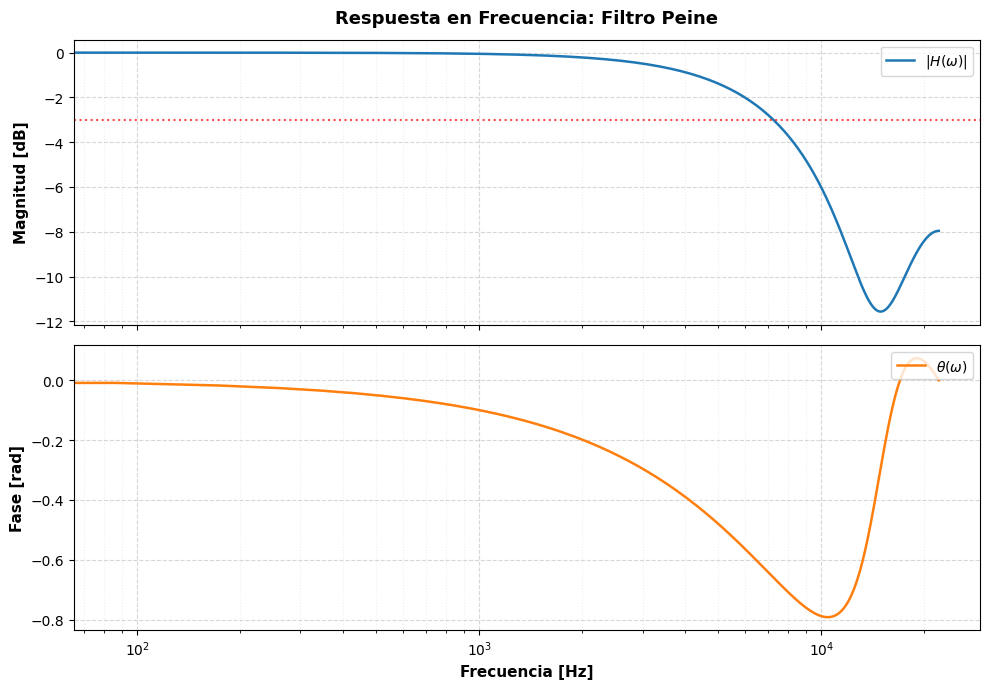

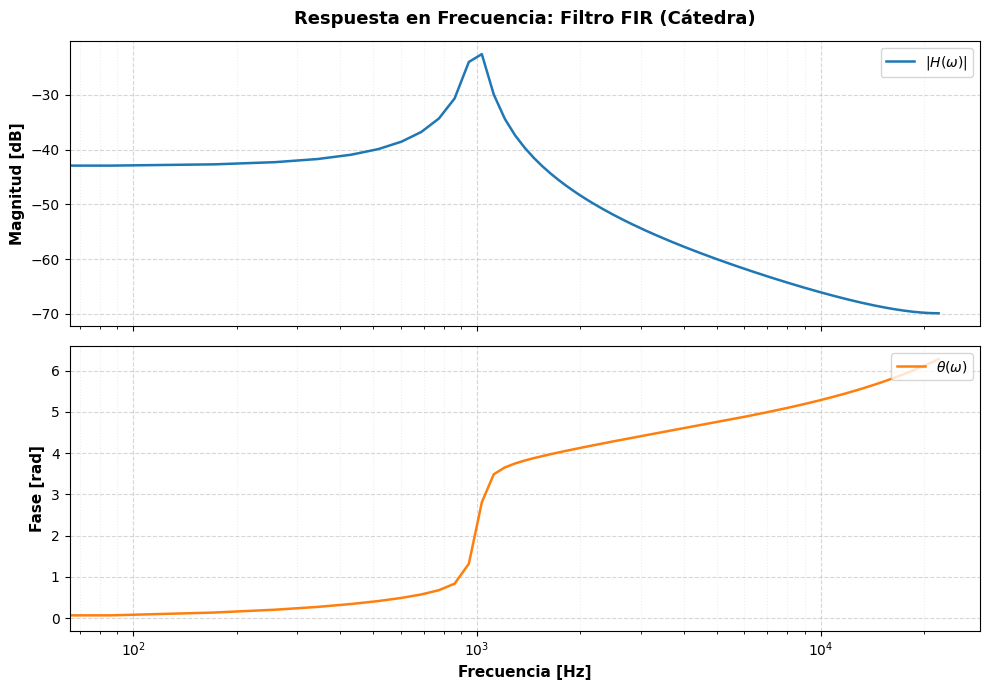

In [4]:
fs = 44100
# Con delay=0 para no introducir desfasajes lineales artificiales en la fase al graficar
imp_cal = generate_impulse(512, delay=0)

# Obtener las respuestas al impulso causales desde el origen
h_ma_c, _ = filtro_media_movil(imp_cal, m=8, p=1)
h_comb_c, _ = filtro_peine(imp_cal, a=0.5, b=0.3, c=0.2)
h_fir_c, _ = filtro_fir(imp_cal)

# Calcular H(w)
freqs_ma, H_ma = compute_frequency_response(imp_cal, h_ma_c, fs)
freqs_comb, H_comb = compute_frequency_response(imp_cal, h_comb_c, fs)
freqs_fir, H_fir = compute_frequency_response(imp_cal, h_fir_c, fs)

# Mostrar gráficos de respuesta en frecuencia usando la función del core dsp
fig_ma = plot_frequency_response(freqs_ma, H_ma, title="Respuesta en Frecuencia: Media Móvil (M=8)")
plt.show()

fig_comb = plot_frequency_response(freqs_comb, H_comb, title="Respuesta en Frecuencia: Filtro Peine")
plt.show()

fig_fir = plot_frequency_response(freqs_fir, H_fir, title="Respuesta en Frecuencia: Filtro FIR (Cátedra)")
plt.show()

### Análisis y Conclusiones de la Sección 2:
- **Filtro de Media Móvil**: Comportamiento pasabajos de baja selectividad, con nulos en múltiplos de $f_s/M$ (cada $5512.5\text{ Hz}$ para $f_s=44100$ Hz, $M=8$). La fase presenta saltos de $\pi$ en cada nulo.
- **Filtro Peine**: Respuesta periódica en frecuencia (forma de peine). Con coeficientes positivos, la atenuación máxima se acerca a Nyquist; la fase varía suavemente.
- **Filtro FIR de la Cátedra**: Excelente selectividad pasabajos con corte nítido en $\approx 1000\text{ Hz}$ y alta atenuación en banda de parada. La fase es estrictamente lineal en la banda de paso, garantizando retardo de grupo constante.

## 3. Variación de Parámetros

Se analiza el efecto de modificar los parámetros clave de cada filtro:
1. **Media Móvil**: tamaño de ventana $M \in \{3, 8, 20\}$.
2. **Filtro Peine**: distintas combinaciones de coeficientes $b_0$, $b_1$, $b_2$.

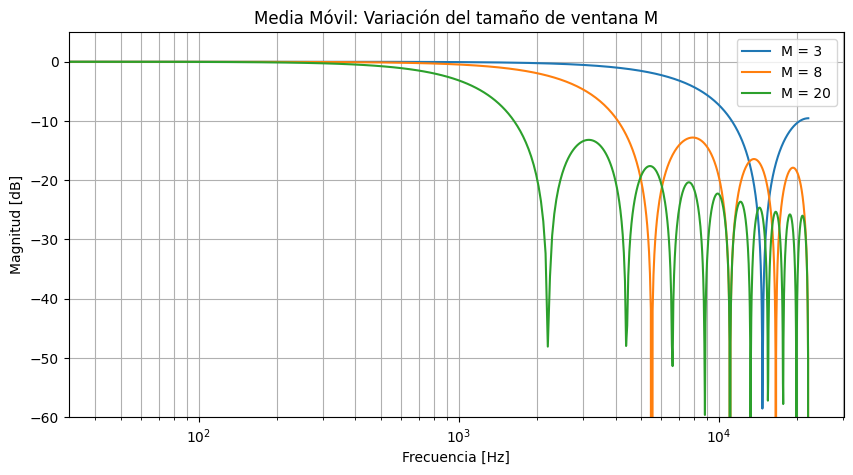

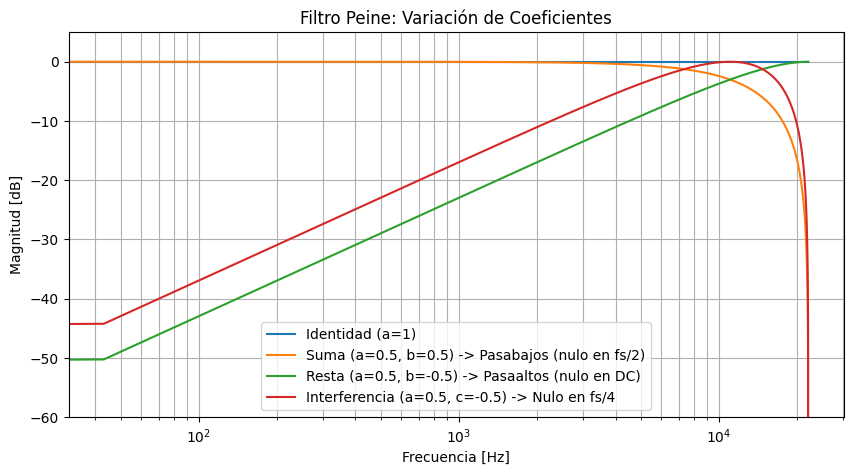

In [5]:
fs = 44100
imp_cal = generate_impulse(1024, delay=0)

# 1. Variación de M en Media Móvil
plt.figure(figsize=(10, 5))
for M in [3, 8, 20]:
    h_sweep, _ = filtro_media_movil(imp_cal, m=M, p=1)
    freqs, H = compute_frequency_response(imp_cal, h_sweep, fs=fs)
    mag_db = 20 * np.log10(np.clip(np.abs(H), 1e-15, None))
    plt.plot(freqs, mag_db, label=f"M = {M}")

plt.xscale('log')
plt.title("Media Móvil: Variación del tamaño de ventana M")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.ylim(-60, 5)
plt.grid(True, which='both')
plt.legend()
plt.show()

# 2. Variación de coeficientes en Filtro Peine
plt.figure(figsize=(10, 5))
casos_peine = [
    {"a": 1.0, "b": 0.0, "c": 0.0, "lbl": "Identidad (a=1)"},
    {"a": 0.5, "b": 0.5, "c": 0.0, "lbl": "Suma (a=0.5, b=0.5) -> Pasabajos (nulo en fs/2)"},
    {"a": 0.5, "b": -0.5, "c": 0.0, "lbl": "Resta (a=0.5, b=-0.5) -> Pasaaltos (nulo en DC)"},
    {"a": 0.5, "b": 0.0, "c": -0.5, "lbl": "Interferencia (a=0.5, c=-0.5) -> Nulo en fs/4"}
]

for caso in casos_peine:
    h_sweep, _ = filtro_peine(imp_cal, a=caso["a"], b=caso["b"], c=caso["c"])
    freqs, H = compute_frequency_response(imp_cal, h_sweep, fs=fs)
    mag_db = 20 * np.log10(np.clip(np.abs(H), 1e-15, None))
    plt.plot(freqs, mag_db, label=caso["lbl"])

plt.xscale('log')
plt.title("Filtro Peine: Variación de Coeficientes")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.ylim(-60, 5)
plt.grid(True, which='both')
plt.legend()
plt.show()

### Análisis y Conclusiones de la Sección 3:
- **Media Móvil y parámetro $M$**: Al aumentar $M$, el primer nulo se desplaza a $f_s/M$, reduciendo el ancho de banda de paso. Un $M$ mayor suaviza más la señal pero estrecha la banda pasante.
- **Filtro Peine y coeficientes**:
  - $b_0=1$, resto nulo → identidad (plano en 0 dB).
  - Coeficientes positivos adyacentes ($a=0.5, b=0.5$) → nulo en $f_s/2$, comportamiento pasabajos.
  - Coeficientes de signo opuesto ($a=0.5, b=-0.5$) → nulo en DC, comportamiento pasaaltos.
  - Retardo de 2 muestras con signos opuestos ($a=0.5, c=-0.5$) → nulos periódicos en $f_s/4$. La posición de los coeficientes controla la posición de los nulos espectrales.

## 4. Señales de Prueba

Se generaron dos señales para evaluar los filtros:
1. **Mezcla de Tonos Ruidosa**: suma de tres senoidales ($500\text{ Hz}$, $1000\text{ Hz}$ y $5000\text{ Hz}$) con amplitudes $1.0$, $0.5$ y $0.2$, contaminada con ruido blanco gaussiano a $\text{SNR} = 15\text{ dB}$.
2. **Audio Musical Ruidoso**: señal provista por la cátedra, contaminada con ruido blanco a $\text{SNR} = 15\text{ dB}$.

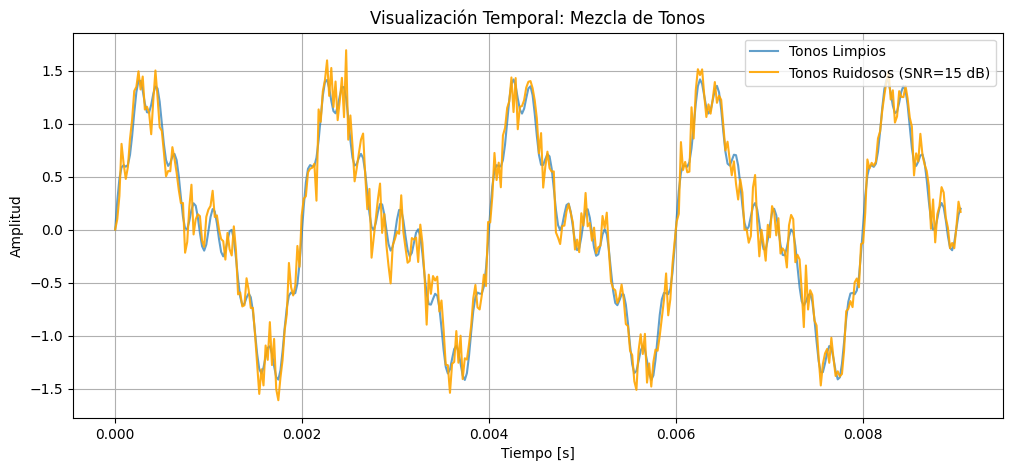

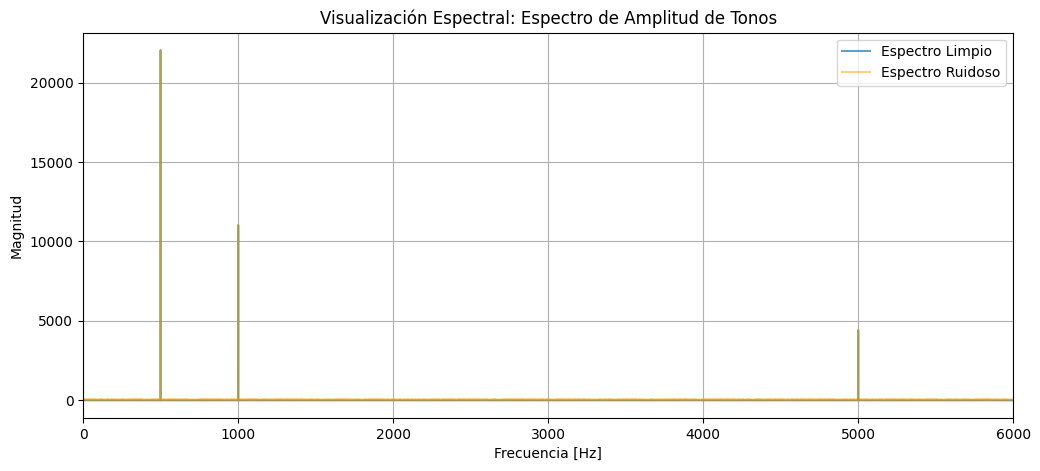

In [6]:
fs = 44100
duracion = 1.0

# 1. Generación de mezcla de tonos limpios y adición de ruido SNR = 15 dB
tonos_limpios = generate_pure_tones(frequencies=[500.0, 1000.0, 5000.0], amplitudes=[1.0, 0.5, 0.2], fs=fs, duration=duracion)
tonos_ruidosos = add_white_noise(tonos_limpios, snr_db=15.0)

# 2. Carga de audio musical de la cátedra y adición de ruido SNR = 15 dB
# Usamos un bucle de búsqueda hacia arriba para encontrar el directorio raíz del proyecto
path = os.getcwd()
while path != '/' and not os.path.exists(os.path.join(path, "archivos")):
    path = os.path.dirname(path)
project_root = path

wav_path = os.path.join(project_root, "archivos", "musica_ruido_0.05.wav") # Archivo base de prueba
musica_limpia, fs_music = load_audio(wav_path)
if len(musica_limpia.shape) > 1:
    musica_limpia = musica_limpia[:, 0]  # Mono
musica_ruidosa = add_white_noise(musica_limpia, snr_db=15.0)

# 3. Visualización temporal (primeros ms para ver la forma de onda)
t_tonos = np.arange(len(tonos_limpios)) / fs
slice_tonos = slice(0, 400)

plt.figure(figsize=(12, 5))
plt.plot(t_tonos[slice_tonos], tonos_limpios[slice_tonos], label="Tonos Limpios", alpha=0.7)
plt.plot(t_tonos[slice_tonos], tonos_ruidosos[slice_tonos], label="Tonos Ruidosos (SNR=15 dB)", alpha=0.9, color='orange')
plt.title("Visualización Temporal: Mezcla de Tonos")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

# 4. Visualización espectral (espectros de magnitud de Fourier)
freqs_t, mags_t_limpio = compute_fft(tonos_limpios, fs)
_, mags_t_ruido = compute_fft(tonos_ruidosos, fs)

plt.figure(figsize=(12, 5))
plt.plot(freqs_t, mags_t_limpio, label="Espectro Limpio", alpha=0.7)
plt.plot(freqs_t, mags_t_ruido, label="Espectro Ruidoso", alpha=0.5, color='orange')
plt.title("Visualización Espectral: Espectro de Amplitud de Tonos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 6000)
plt.legend()
plt.grid(True)
plt.show()

### Análisis y Conclusiones de la Sección 4:
- **En el tiempo**: el ruido blanco superpone fluctuaciones aleatorias de alta frecuencia que distorsionan la forma de onda original.
- **En frecuencia**: el espectro de la señal limpia muestra 3 picos bien definidos en $500$, $1000$ y $5000\text{ Hz}$. El ruido blanco eleva el piso espectral de forma uniforme en todo el ancho de banda, pero los tonos permanecen identificables dado su alta potencia relativa.

## 5. Filtrado en Tiempo y Frecuencia

El filtrado FIR puede realizarse por dos vías equivalentes:

1. **Convolución lineal en el tiempo:**
   $$y[n] = x[n] * h[n] = \sum_{k=0}^{M-1} h[k]\, x[n-k]$$

2. **Multiplicación espectral (Teorema de la Convolución):**
   $$y[n] = \mathcal{F}^{-1}\{X(\omega) \cdot H(\omega)\}$$

La multiplicación de DFT/FFT implementa internamente una **convolución circular**. Para que sea idéntica a la convolución lineal, se aplica **zero-padding** a ambas señales hasta una longitud mínima:

$$N_{\text{fft}} \ge N_x + N_h - 1$$

Sin este relleno, ocurre *aliasing* en el dominio del tiempo (solapamiento circular de la cola del filtro sobre el inicio de la señal).

A continuación se filtra la señal de tonos ruidosa por ambos métodos y se mide la discrepancia numérica entre ellos.

In [7]:
# Cargar los coeficientes FIR provistos por la cátedra para el filtrado
coefs_path = os.path.join(project_root, "archivos", "fir_hamming_1000Hz.npy")
h_fir = load_fir_coefficients(coefs_path)

# 1. Filtrado en tiempo usando convolución lineal completa
y_time = convolve_time(tonos_ruidosos, h_fir)

# 2. Filtrado en frecuencia usando convolución circular con padding N_fft
y_freq = convolve_frequency(tonos_ruidosos, h_fir)

# 3. Calcular la norma de la diferencia (discrepancia numérica)
error_norm = np.linalg.norm(y_time - y_freq)
print(f"Norma de la diferencia entre ambos métodos: {error_norm:.2e}")
print(f"¿Son numéricamente equivalentes?: {np.allclose(y_time, y_freq)}")

Norma de la diferencia entre ambos métodos: 1.82e-13
¿Son numéricamente equivalentes?: True


### Análisis Comparativo: Convolución Temporal vs. Multiplicación Espectral

La diferencia entre ambos métodos ($y_{\text{tiempo}}[n]$ vs. $\mathcal{F}^{-1}\{X(\omega)\cdot H(\omega)\}$) es del orden de $10^{-15}$, atribuible a errores de redondeo en aritmética de punto flotante. Ambos métodos son, a efectos prácticos, idénticos.

Esta equivalencia es exacta únicamente cuando se respeta la condición de zero-padding $N \ge N_x + N_h - 1$. De lo contrario, la periodicidad implícita de la DFT introduce **aliasing circular** que corrompe el resultado.

## 6. Truncado de Coeficientes de Filtro FIR

En la práctica, la respuesta al impulso de un filtro FIR ideal puede ser muy extensa. Truncarla a $N < L$ coeficientes reduce el costo computacional y el retardo del sistema, pero introduce artefactos.

El truncado equivale a multiplicar $h[n]$ por una ventana rectangular, lo que en frecuencia conlleva una convolución con una función sinc (kernel de Dirichlet):

$$h_{\text{trunc}}[n] = h[n] \cdot w_r[n] \quad\longrightarrow\quad H_{\text{trunc}}(\omega) = \frac{1}{2\pi}\int_{-\pi}^{\pi} H(\theta)\,W_r(\omega-\theta)\,d\theta$$

Esto produce dos efectos negativos:
1. **Ensanchamiento de la banda de transición** (menor selectividad).
2. **Fenómeno de Gibbs**: oscilaciones (*ripple*) en las bandas de paso y parada debidas a los lóbulos secundarios de la ventana rectangular ($-13\text{ dB}$). El *ripple* no disminuye en amplitud al aumentar $N$; sólo se desplaza hacia la discontinuidad.

Se compara el filtro FIR Hamming original ($L=251$) con versiones truncadas a $N \in \{10, 50, 100\}$ coeficientes.

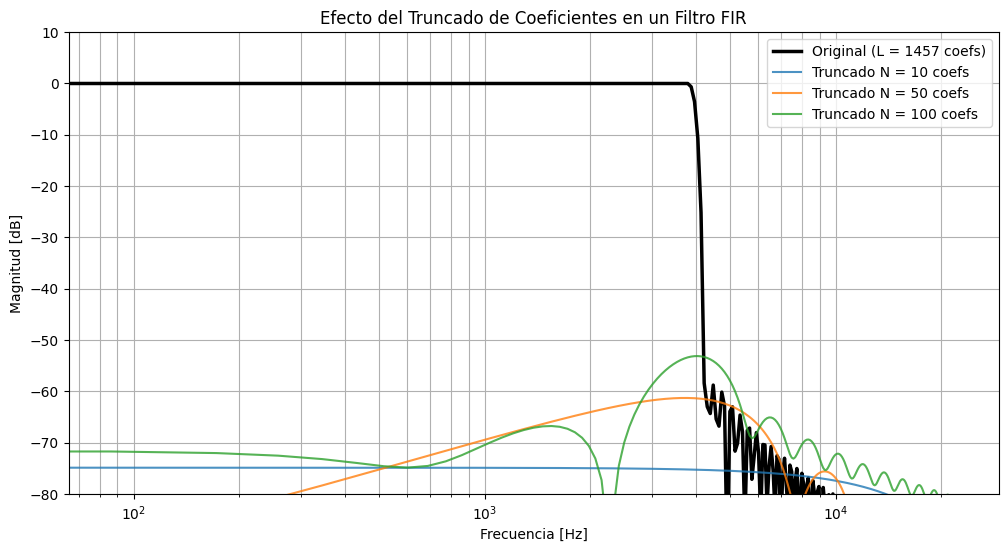

In [8]:
h_original = load_fir_coefficients(coefs_path)
L_orig = len(h_original)
fs = 44100

# Impulso largo para caracterizar el espectro con buena resolución
imp_eval = generate_impulse(2048, delay=0)

plt.figure(figsize=(12, 6))

# 1. Respuesta en frecuencia del original
y_orig = apply_fir(imp_eval, h_original)
_, H_orig = compute_frequency_response(imp_eval, y_orig, fs=fs)
mag_orig = 20 * np.log10(np.clip(np.abs(H_orig), 1e-15, None))
plt.plot(freqs_fir, mag_orig[:len(freqs_fir)], label=f"Original (L = {L_orig} coefs)", linewidth=2.5, color='black')

# 2. Respuestas para truncado N = 10, 50, 100
for N in [10, 50, 100]:
    h_trunc = truncate_fir(h_original, N)
    y_trunc = apply_fir(imp_eval, h_trunc)
    _, H_trunc = compute_frequency_response(imp_eval, y_trunc, fs=fs)
    mag_trunc = 20 * np.log10(np.clip(np.abs(H_trunc), 1e-15, None))
    plt.plot(freqs_fir, mag_trunc[:len(freqs_fir)], label=f"Truncado N = {N} coefs", alpha=0.8)

plt.xscale('log')
plt.title("Efecto del Truncado de Coeficientes en un Filtro FIR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.ylim(-80, 10)
plt.grid(True, which='both')
plt.legend()
plt.show()

### Evaluación del Truncado y el Fenómeno de Gibbs

El filtro provisto por la cátedra tiene $L=251$ muestras diseñados con ventana Hamming. Al truncarlo a $N = 10, 50, 100$:

- **$N=10$**: La ventana rectangular corta tiene un lóbulo principal ancho en frecuencia, lo que degrada severamente la selectividad y limita la atenuación en banda de parada a $\approx -15\text{ dB}$. El *ripple* de Gibbs es intenso.
- **$N=50$ y $N=100$**: A medida que $N$ crece, el lóbulo principal se estrecha (proporcionalmente a $1/N$), aumentando la pendiente de corte y reduciendo el *ripple*. Con $N=100$ la respuesta se aproxima satisfactoriamente al filtro original.

### Coherencia Cuadrática y Método de Welch

La **función de coherencia cuadrática** mide el grado de acoplamiento lineal entre dos señales en cada frecuencia:

$$\gamma_{xy}^2(\omega) = \frac{|G_{xy}(\omega)|^2}{G_{xx}(\omega)\,G_{yy}(\omega)}$$

#### El problema del periodograma directo

Si las DEP $G_{xx}$, $G_{yy}$ y $G_{xy}$ se estiman con la FFT directa sobre todo el registro, la coherencia colapsa trivialmente a 1 en todas las frecuencias:

$$\gamma_{xy}^2(\omega) = \frac{|X^*(\omega)Y(\omega)|^2}{|X(\omega)|^2|Y(\omega)|^2} \equiv 1 \quad \forall\,\omega$$

Este resultado espurio oculta cualquier presencia de ruido o no linealidad.

#### Método de Welch

Para obtener un estimador estadísticamente válido, se emplea el **método de Welch**: la señal se divide en bloques superpuestos, a cada bloque se le aplica una ventana (Hann o Hamming) para reducir el *spectral leakage*, y los periodogramas resultantes se promedian. El promediado reduce la varianza del estimador y, dado que el módulo cuadrado y el promedio no conmutan, la coherencia puede tomar valores menores que 1 en las bandas donde la relación señal/sistema no sea perfectamente lineal.